Rows: 55 Columns: 16
-- Column specification --------------------------------------------------------
Delimiter: "\t"
chr  (2): sample_id, condition
dbl (14): size, richness, d1, shannon, d2, simpson, d3, d4, chao1, ace, gini...

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.


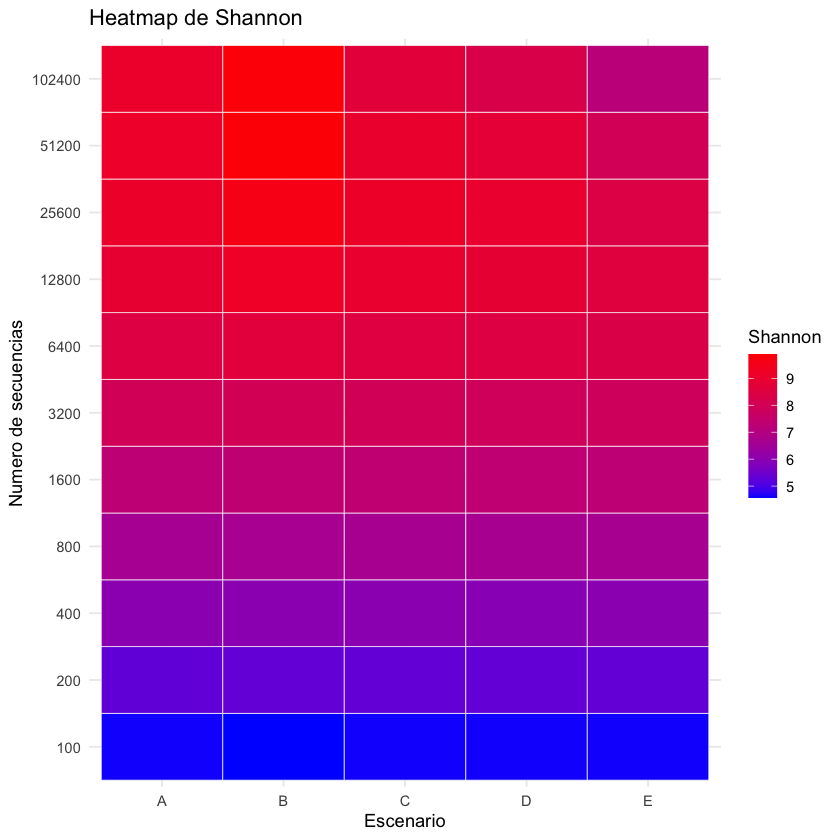

In [ ]:
library(readr)
library(ggplot2)


df <- read_tsv("../results/diversity_matrix/diversity_matrix_A.tsv")
library(ggplot2)

ggplot(df,
       aes(x = condition,
           y = factor(size),
           fill = shannon)) +
  geom_tile(color = "white") +
  scale_fill_gradient(low = "blue", high = "red") +
  theme_minimal() +
  labs(
    title = "Heatmap de Shannon",
    x = "Escenario",
    y = "Numero de secuencias",
    fill = "Shannon"
  )



## Generación de heatmaps de métricas de diversidad

Se procesó la matriz de métricas de diversidad utilizando **R**, con el objetivo de visualizar el comportamiento de cada métrica en los distintos escenarios simulados mediante **heatmaps**.

### Librerías utilizadas

* **readr**: lectura de archivos TSV.
* **dplyr**: manipulación y transformación de datos.
* **tidyr**: reorganización del formato de la tabla.
* **ggplot2**: generación de los heatmaps.
* **patchwork**: combinación de múltiples gráficos en una sola figura.

### Lectura de datos

* **read_tsv()**: importa la matriz de diversidad en un *data frame* para su posterior análisis.

### Selección de métricas

* **metrics_keep**: vector que contiene las métricas de diversidad que serán incluidas en la visualización.

### Transformación de la tabla

* **pivot_longer()**: convierte la tabla de formato ancho a formato largo, generando una columna con el nombre de la métrica (`metric`) y otra con su valor (`value`).

### Normalización de los datos

* **group_by(metric)**: agrupa los datos por cada métrica de diversidad.
* **scale()**: calcula el z-score de cada métrica de forma independiente, permitiendo comparar métricas que poseen escalas diferentes.
* **ungroup()**: elimina la agrupación una vez finalizada la normalización.

### Generación de los heatmaps

* **lapply()**: recorre cada métrica y genera automáticamente un heatmap.
* **ggplot()**: construye el gráfico utilizando:

  * **condition**: escenarios simulados (eje X).
  * **size**: número de secuencias (eje Y).
  * **value_scaled**: valor normalizado representado mediante una escala de color.

### Personalización de la figura

* **geom_tile()**: representa cada combinación de escenario y tamaño mediante un rectángulo coloreado.
* **scale_fill_gradient()**: asigna una escala de colores según el z-score (azul para valores bajos y rojo para valores altos).
* **theme()**: ajusta títulos, tamaño de texto y apariencia general del gráfico.

### Combinación de gráficos

* **wrap_plots()**: organiza todos los heatmaps en una única figura.
* **plot_layout(guides = "collect")**: utiliza una barra de colores compartida para todas las métricas.


In [1]:
library(patchwork)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Rows: 55 Columns: 16
-- Column specification --------------------------------------------------------
Delimiter: "\t"
chr  (2): sample_id, condition
dbl (14): size, richness, d1, shannon, d2, simpson, d3, d4, chao1, ace, gini...

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.


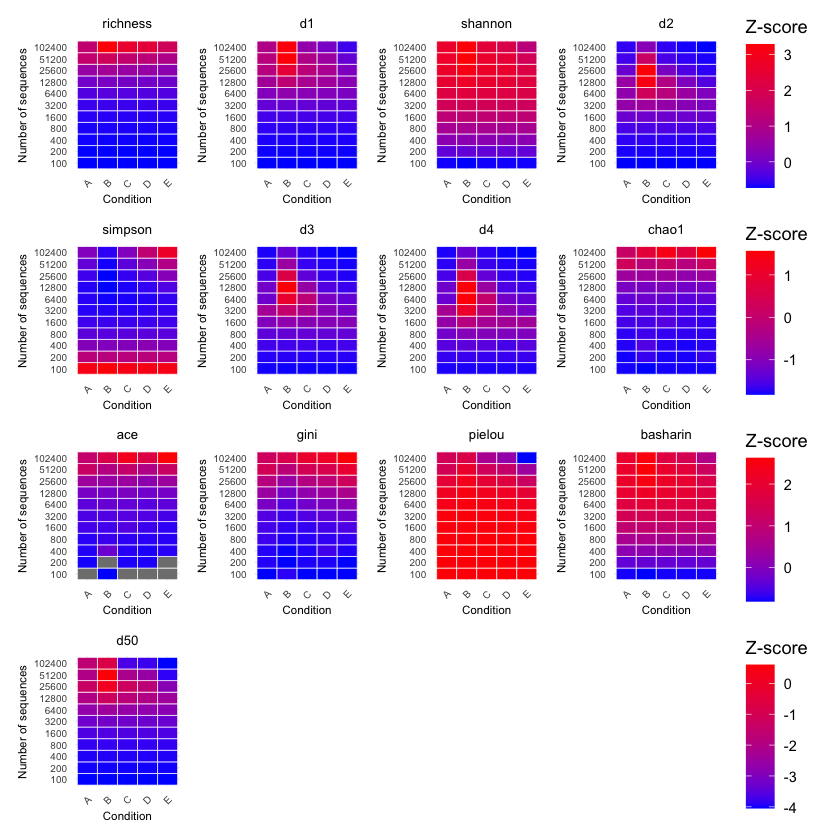

In [2]:
library(readr)
library(dplyr)
library(tidyr)
library(ggplot2)
library(patchwork)

# Leer datos
df <- read_tsv("../results/diversity_matrix/diversity_matrix_A.tsv")

# Métricas que quieres usar
metrics_keep <- c(
  "richness", "d1", "shannon", "d2", "simpson", "d3", "d4",
  "chao1", "ace", "gini", "pielou", "basharin", "d50"
)

# Pasar a formato largo + filtrar métricas + z-score
df_long <- df %>%
  pivot_longer(
    cols = all_of(metrics_keep),
    names_to = "metric",
    values_to = "value"
  ) %>%
  group_by(metric) %>%
  mutate(value_scaled = as.numeric(scale(value))) %>%
  ungroup()

# Crear lista de plots
plots <- lapply(unique(df_long$metric), function(m) {

  ggplot(
    filter(df_long, metric == m),
    aes(
      x = condition,
      y = factor(size),
      fill = value_scaled
    )
  ) +
    geom_tile(color = "white") +
    scale_fill_gradient(
      low = "blue",
      high = "red"
    ) +
    theme_minimal() +
    labs(
      title = m,
      x = "Condition",
      y = "Number of sequences",
      fill = "Z-score"
    ) +
   theme(
  plot.title = element_text(hjust = 0.5, size = 8),
  axis.text.x = element_text(angle = 45, hjust = 1, size = 6),
  axis.text.y = element_text(size = 6),
  axis.title = element_text(size = 7)
)
})

# Unir todos los gráficos
final_plot <- wrap_plots(plots, ncol = 4) +
  plot_layout(guides = "collect")

# Mostrar
final_plot

